# HyPhy Omega Distribution Plots

Generates omega distribution plots found in [Fig. 2](figures/figure_2), [Fig. 3](figures/figure_3), and [Fig. 4](figures/figure_4)

## Notebook Workflow

1. Load cached HyPhy result objects (RELAX and BUSTED variants).
2. Filter extreme omega outliers for stable visual summaries.
3. Generate omega distribution plots for each analysis branch.
4. Export publication-ready omega figure panels to the figures directory.

In [17]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=SyntaxWarning)

In [ ]:
import sys
import os
import matplotlib.pyplot as plt
import pandas as pd

pd.set_option('display.max_columns', None, 'display.max_rows', 50)

# Resolve repo root whether cwd is repo root, scripts/, or a stage subdirectory.
cwd = os.getcwd()
if os.path.basename(cwd) == "orb-selection":
    repo_root = cwd
elif os.path.basename(os.path.dirname(cwd)) == "orb-selection":
    repo_root = os.path.dirname(cwd)
elif os.path.basename(os.path.dirname(os.path.dirname(cwd))) == "orb-selection":
    repo_root = os.path.dirname(os.path.dirname(cwd))
else:
    repo_root = cwd

src_path = os.path.join(repo_root, "src")
stage03_path = os.path.join(repo_root, "scripts", "03_selection_tests")
stage06_path = os.path.join(repo_root, "scripts", "06_figures_tables")
for path in (src_path, stage03_path, stage06_path):
    if path not in sys.path:
        sys.path.append(path)

print(f"Using src path: {src_path}")
print(f"Using stage-03 path: {stage03_path}")
print(f"Using stage-06 path: {stage06_path}")

from hyphy_results_parser import (
    RelaxResult,
    BustedPhResult
)
from omega_plots import plot_omega_distributions, plot_omega_single_gene

figures = os.path.join(repo_root, "figures")
hyphy_results = os.path.join(repo_root, "results", "hyphy_results_cache")

Using src path: /Users/calvin/orb-selection/src
Using stage-03 path: /Users/calvin/orb-selection/scripts/03_selection_tests
Using stage-06 path: /Users/calvin/orb-selection/scripts/06_figures_tables


In [19]:
%load_ext autoreload


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
# Load the saved RELAX results
relax_result = RelaxResult.load_from_pickle(os.path.join(hyphy_results, "relax_results.pkl"))

# Load the saved BUSTED-PH, orb fg results
busted_ph_orb_result = BustedPhResult.load_from_pickle(os.path.join(hyphy_results, "busted_ph_orb_results.pkl"))

# Load the saved BUSTED-PH, non-orb fg results
busted_ph_non_orb_result = BustedPhResult.load_from_pickle(os.path.join(hyphy_results, "busted_ph_non_orb_results.pkl"))

Filter out extremely large omega values from the results (arbitrary threshold of 10,000)

In [21]:
relax_result_fltrd = relax_result.filter_omega(10000)
busted_ph_orb_result_fltrd = busted_ph_orb_result.filter_omega(10000)
busted_ph_non_orb_result_fltrd = busted_ph_non_orb_result.filter_omega(10000)

In [22]:
relax_df_fltrd = relax_result_fltrd.results_df
busted_ph_non_orb_df_fltrd = busted_ph_non_orb_result_fltrd.results_df
busted_ph_orb_df_fltrd = busted_ph_orb_result_fltrd.results_df

## Omega plots

mean ω values for test: ω1=0.0268, ω2=0.2876, ω3=12794.5424
mean site proportions for test: ω1=0.6075, ω2=0.3852, ω3=0.0074
mean ω values for ref: ω1=0.0160, ω2=0.1449, ω3=12.8766
mean site proportions for ref: ω1=0.4617, ω2=0.4755, ω3=0.0628


(<Figure size 600x500 with 5 Axes>, array([<Axes: >, <Axes: >], dtype=object))

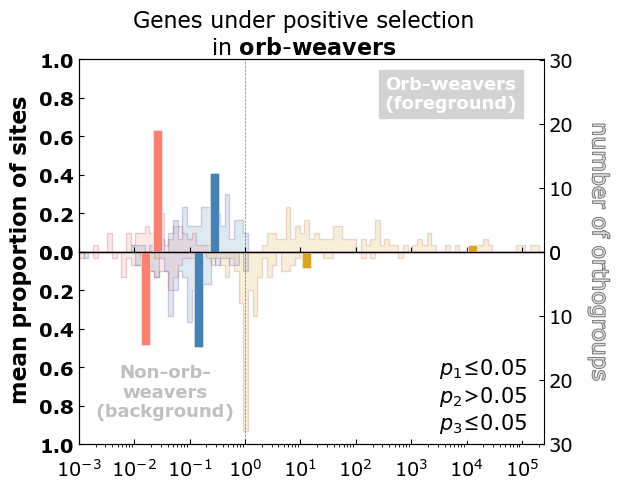

In [23]:
%autoreload 2
x=busted_ph_orb_df_fltrd[busted_ph_orb_df_fltrd['result']=='hit']
result='busted'
top_title = 'Orb-weavers\n(foreground)'
bottom_title = 'Non-orb-\nweavers\n(background)'

%autoreload 2
plot_omega_distributions(
    x, 
    result, 
    top_title, 
    bottom_title, 
    suptitle="Genes under positive selection\nin "+ r'$\bf{orb}$'+ "-" + r'$\bf{weavers}$',
    filename=os.path.join(figures, 'figure_4/busted_ph_orb_omega_dist.png'),
    transparent=True,
    xlim_max=250000
    )

mean ω values for test: ω1=0.0222, ω2=0.3501, ω3=182354.6330
mean site proportions for test: ω1=0.6168, ω2=0.3669, ω3=0.0163
mean ω values for ref: ω1=0.0180, ω2=0.1498, ω3=81.6313
mean site proportions for ref: ω1=0.4462, ω2=0.4614, ω3=0.0923


(<Figure size 600x500 with 5 Axes>, array([<Axes: >, <Axes: >], dtype=object))

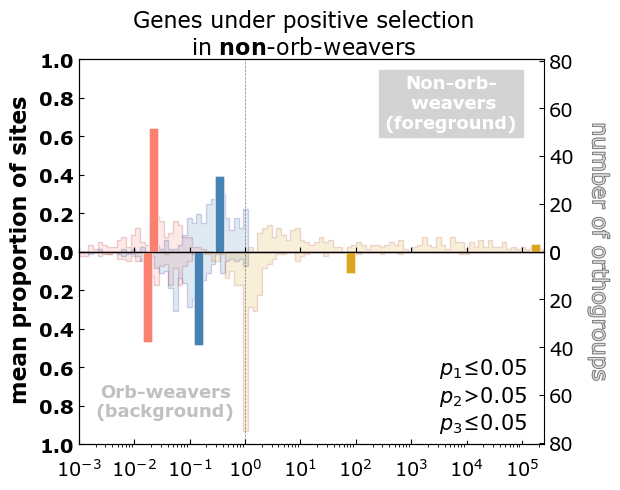

In [24]:
%autoreload 2
x=busted_ph_non_orb_df_fltrd[busted_ph_non_orb_df_fltrd['result']=='hit']
result='busted'
top_title = 'Non-orb-\n weavers\n(foreground)'
bottom_title = 'Orb-weavers\n(background)'

plot_omega_distributions(
    x, 
    result, 
    top_title, 
    bottom_title, 
    suptitle="Genes under positive selection\nin " + r'$\bf{non}$' + "-orb-weavers",
    filename=os.path.join(figures, 'figure_4/busted_ph_non_orb_omega_dist.png'),
    transparent=True,
    xlim_max=250000,
    shift_top_title=True
    )

mean ω values for test: ω1=0.0129, ω2=0.1888, ω3=17393.7575
mean site proportions for test: ω1=0.7059, ω2=0.2383, ω3=0.0558
mean ω values for ref: ω1=0.0140, ω2=0.1915, ω3=12364.9275
mean site proportions for ref: ω1=0.7060, ω2=0.2382, ω3=0.0558


(<Figure size 600x500 with 5 Axes>, array([<Axes: >, <Axes: >], dtype=object))

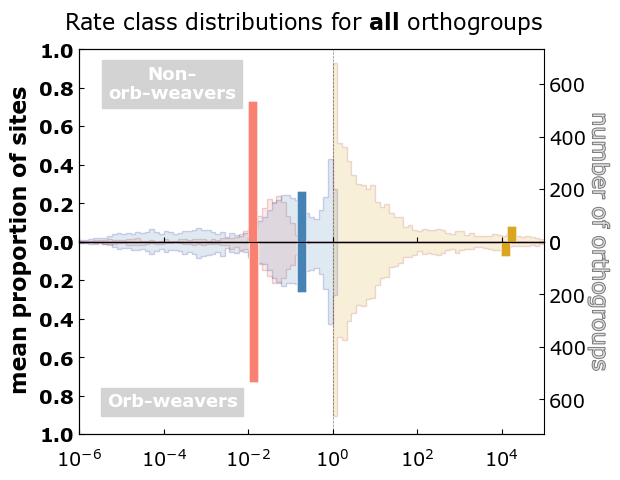

In [25]:
x=relax_df_fltrd

result='all'
top_title = 'Non-\norb-weavers'
bottom_title = 'Orb-weavers'

plot_omega_distributions(
    x, 
    result, 
    top_title, 
    bottom_title, 
    suptitle="Rate class distributions for " + r"$\bf{all}$" + " orthogroups",
    filename=os.path.join(figures, 'figure_2/relax_all_omega_dist.png'),
    transparent=False,
    xlim_min=0.000001
    )

mean ω values for test: ω1=0.0198, ω2=0.2213, ω3=1426.7261
mean site proportions for test: ω1=0.6706, ω2=0.2755, ω3=0.0540
mean ω values for ref: ω1=0.0132, ω2=0.1851, ω3=7194.4081
mean site proportions for ref: ω1=0.6706, ω2=0.2755, ω3=0.0540


(<Figure size 600x500 with 5 Axes>, array([<Axes: >, <Axes: >], dtype=object))

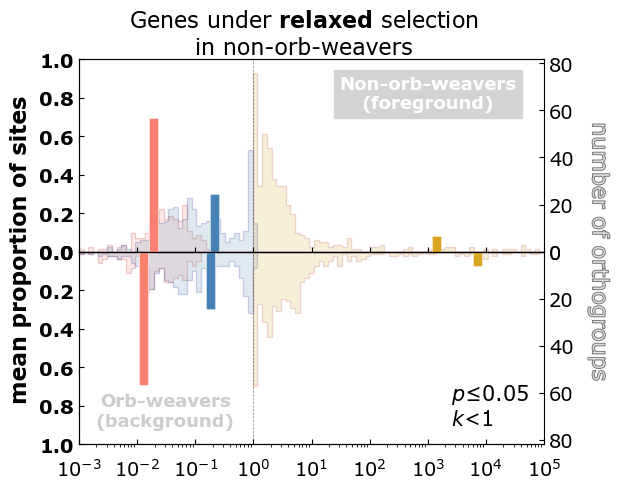

In [26]:
%autoreload 2
x=relax_df_fltrd[relax_df_fltrd['result']=='relaxed']
result='relaxed'
top_title = 'Non-orb-weavers\n(foreground)' 
bottom_title = 'Orb-weavers\n(background)' 

plot_omega_distributions(
    x, 
    result, 
    top_title, 
    bottom_title,
    suptitle="Genes under " + r"$\bf{relaxed}$" + " selection\nin non-orb-weavers", 
    filename=os.path.join(figures, 'figure_3/relax_relaxed_omega_dist.png'),
    transparent=True,
    )

mean ω values for test: ω1=0.0250, ω2=0.1891, ω3=38760.3644
mean site proportions for test: ω1=0.6671, ω2=0.2990, ω3=0.0339
mean ω values for ref: ω1=0.0346, ω2=0.2225, ω3=8296.7792
mean site proportions for ref: ω1=0.6677, ω2=0.2984, ω3=0.0339


(<Figure size 600x500 with 5 Axes>, array([<Axes: >, <Axes: >], dtype=object))

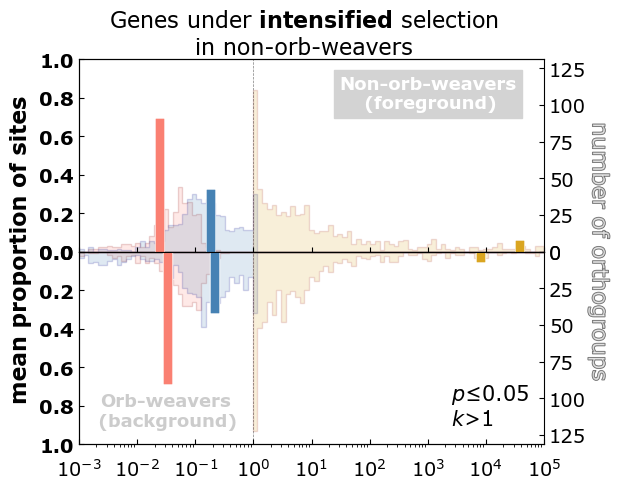

In [27]:
x=relax_df_fltrd[relax_df_fltrd['result']=='intensified']
result='intensified'
top_title = 'Non-orb-weavers\n (foreground)'
bottom_title = 'Orb-weavers\n (background)'

%autoreload 2
plot_omega_distributions(
    x, 
    result, 
    top_title, 
    bottom_title, 
    suptitle="Genes under " + r"$\bf{intensified}$" + " selection\nin non-orb-weavers", 
    filename=os.path.join(figures, 'figure_3/relax_intensified_omega_dist.png'),
    transparent=True
)

# Plot example genes from each selection pattern

## Relaxed

ω values for N5.HOG0025053: ω1_test=0.0023, ω2_test=0.0644, ω3_test=1.0813,
ω1_ref=0.0012, ω2_ref=0.0477, ω3_ref=1.0906;
Proportions: ω1_test_P=0.7789, ω2_test_P=0.2211, ω3_test_P=0.0000,
ω1_ref_P=0.7789, ω2_ref_P=0.2211, ω3_ref_P=0.0000


(<Figure size 550x500 with 1 Axes>,
 <Axes: title={'center': 'Relaxation of negative selection in non-orb-weavers'}>)

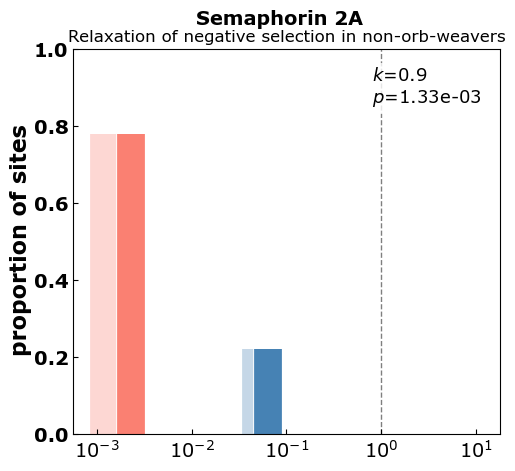

In [28]:
%autoreload 2
plot_omega_single_gene(
    relax_df_fltrd, 
    'N5.HOG0025053', 
    k=True,
    suptitle="Semaphorin 2A",
    subtitle="Relaxation of negative selection in non-orb-weavers",
    transparent=False,
    # xlim_min=0.0005
    )

plotting marker: omega=26.48123452421653, proportion=0.002894965162699802
plotting marker: omega=16.11215526283636, proportion=0.002894965162699802
ω values for N5.HOG0067320: ω1_test=0.0089, ω2_test=0.3910, ω3_test=16.1122,
ω1_ref=0.0038, ω2_ref=0.3305, ω3_ref=26.4812;
Proportions: ω1_test_P=0.9174, ω2_test_P=0.0797, ω3_test_P=0.0029,
ω1_ref_P=0.9174, ω2_ref_P=0.0797, ω3_ref_P=0.0029


(<Figure size 550x500 with 1 Axes>,
 <Axes: title={'center': 'Relaxation of selection in non-orb-weavers'}>)

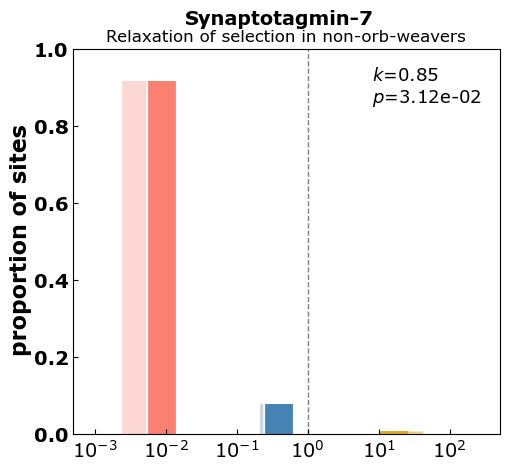

In [29]:
%autoreload 2
plot_omega_single_gene(
    relax_df_fltrd, 
    'N5.HOG0067320', 
    suptitle="Synaptotagmin-7",
    subtitle="Relaxation of selection in non-orb-weavers",
    k=True,
    transparent=False,
    xlim_min=0.0005,
    xlim_max=500,
    )

ω values for N5.HOG0063077: ω1_test=0.0268, ω2_test=0.0733, ω3_test=1.1747,
ω1_ref=0.0161, ω2_ref=0.0507, ω3_ref=1.2016;
Proportions: ω1_test_P=0.4219, ω2_test_P=0.5781, ω3_test_P=0.0000,
ω1_ref_P=0.4219, ω2_ref_P=0.5781, ω3_ref_P=0.0000


(<Figure size 550x500 with 1 Axes>,
 <Axes: title={'center': 'Relaxation of selection in non-orb-weavers'}>)

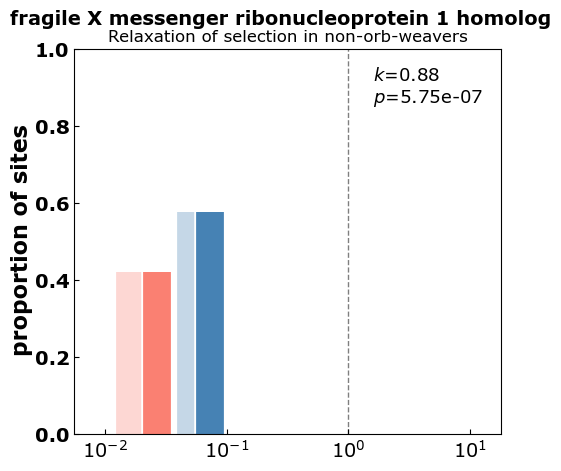

In [30]:
%autoreload 2
plot_omega_single_gene(
    relax_df_fltrd, 
    'N5.HOG0063077', 
    suptitle="fragile X messenger ribonucleoprotein 1 homolog",
    subtitle="Relaxation of selection in non-orb-weavers",
    k=True,
    transparent=False,
    # xlim_min=0.0005
    )

ω values for N5.HOG0039805: ω1_test=0.0176, ω2_test=0.9843, ω3_test=4.2357,
ω1_ref=0.0000, ω2_ref=0.9159, ω3_ref=3023.6440;
Proportions: ω1_test_P=0.8474, ω2_test_P=0.0514, ω3_test_P=0.1012,
ω1_ref_P=0.8474, ω2_ref_P=0.0514, ω3_ref_P=0.1012


(<Figure size 550x500 with 1 Axes>, <Axes: >)

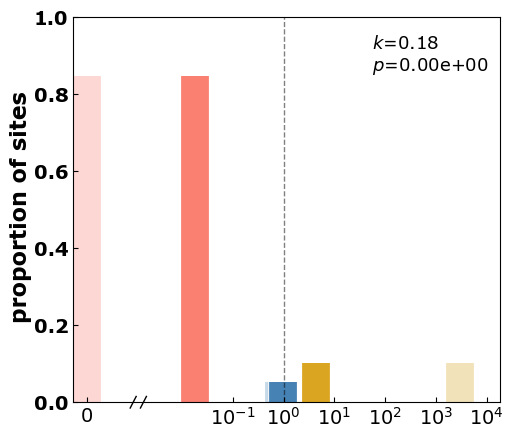

In [50]:
%autoreload 2
plot_omega_single_gene(
    relax_df_fltrd, 
    'N5.HOG0039805', 
    # suptitle="Uncharacterized protein with possible G-protein coupled receptor activity",
    # subtitle="Relaxation of selection in non-orb-weavers",
    k=True,
    transparent=False,
    offset_zero_w2=True,
    filename=os.path.join(figures, 'figure_3/relax_relaxed_single_gene.png')
    )

ω values for N5.HOG0058518: ω1_test=0.0298, ω2_test=0.1079, ω3_test=1.0585,
ω1_ref=0.0149, ω2_ref=0.0696, ω3_ref=1.0705;
Proportions: ω1_test_P=0.6607, ω2_test_P=0.3393, ω3_test_P=0.0000,
ω1_ref_P=0.6607, ω2_ref_P=0.3393, ω3_ref_P=0.0000


(<Figure size 550x500 with 1 Axes>,
 <Axes: title={'center': 'Relaxation of negative selection in non-orb-weavers'}>)

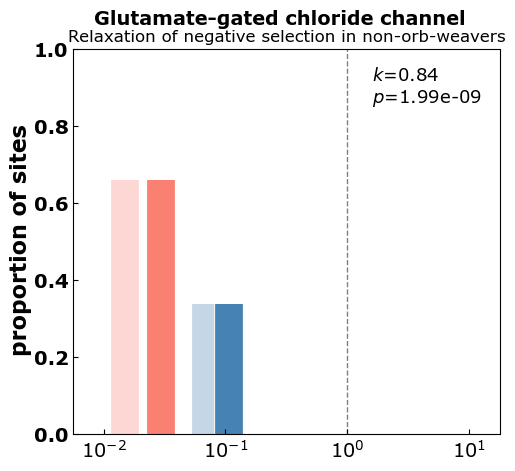

In [32]:
%autoreload 2
plot_omega_single_gene(
    relax_df_fltrd, 
    'N5.HOG0058518', 
    suptitle="Glutamate-gated chloride channel",
    subtitle="Relaxation of negative selection in non-orb-weavers",
    k=True,
    transparent=False,
    )

ω values for N5.HOG0023158: ω1_test=0.1157, ω2_test=0.1252, ω3_test=1.0027,
ω1_ref=0.0846, ω2_ref=0.0926, ω3_ref=1.0031;
Proportions: ω1_test_P=0.1688, ω2_test_P=0.8312, ω3_test_P=0.0000,
ω1_ref_P=0.1688, ω2_ref_P=0.8312, ω3_ref_P=0.0000


(<Figure size 550x500 with 1 Axes>,
 <Axes: title={'center': 'Relaxation in non-orb-weavers'}>)

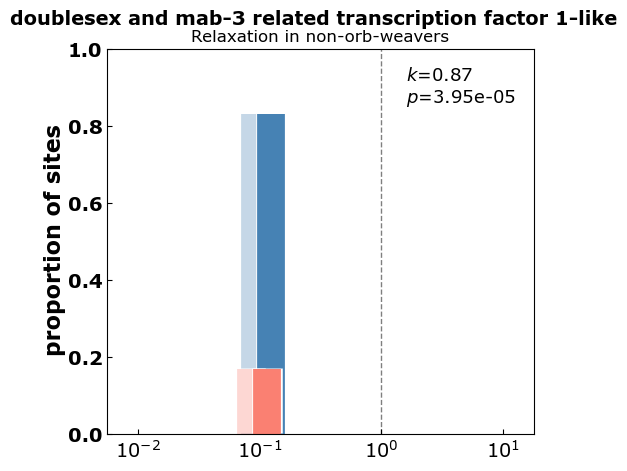

In [33]:
%autoreload 2
plot_omega_single_gene(
    relax_df_fltrd, 
    'N5.HOG0023158', 
    suptitle="doublesex and mab-3 related transcription factor 1-like",
    subtitle="Relaxation in non-orb-weavers",
    k=True,
    transparent=False,
    zorder_1ref=2,
    zorder_1test=2
    )

ω values for N5.HOG0067223: ω1_test=0.0000, ω2_test=0.0000, ω3_test=3.2216,
ω1_ref=0.0000, ω2_ref=0.0000, ω3_ref=5.7511;
Proportions: ω1_test_P=0.6918, ω2_test_P=0.1394, ω3_test_P=0.1688,
ω1_ref_P=0.6918, ω2_ref_P=0.1394, ω3_ref_P=0.1688


/Users/calvin/orb-selection/scripts/07_figures_tables/omega_plots_consolidated.py:288: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['ω1_test'] = 0


(<Figure size 550x500 with 1 Axes>,
 <Axes: title={'center': 'Relaxation in non-orb-weavers'}>)

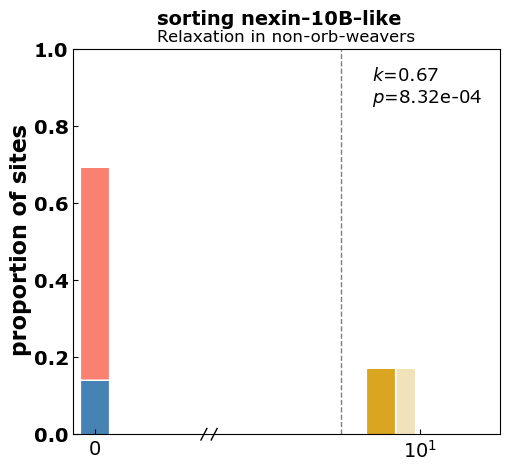

In [34]:
plot_omega_single_gene(
    relax_df_fltrd, 
    'N5.HOG0067223', 
    suptitle="sorting nexin-10B-like",
    subtitle="Relaxation in non-orb-weavers",
    k=True,
    transparent=False,
    # xlim_min=0.0005,
    xlim_max=100,
    )

## Intensified

plotting marker: omega=14.9455736719643, proportion=0.0006748486559947559
plotting marker: omega=24.13911442513839, proportion=0.0006748486559947559
ω values for N5.HOG0060437: ω1_test=0.0067, ω2_test=0.0765, ω3_test=24.1391,
ω1_ref=0.0142, ω2_ref=0.1127, ω3_ref=14.9456;
Proportions: ω1_test_P=0.9894, ω2_test_P=0.0099, ω3_test_P=0.0007,
ω1_ref_P=0.9894, ω2_ref_P=0.0099, ω3_ref_P=0.0007


(<Figure size 550x500 with 1 Axes>,
 <Axes: title={'center': 'Intensification in non-orb-weavers'}>)

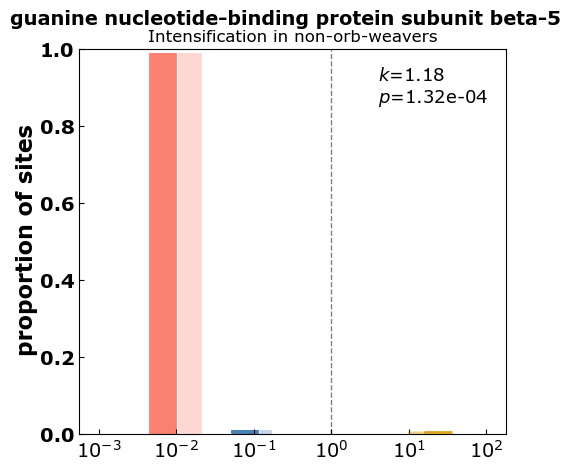

In [35]:
%autoreload 2

plot_omega_single_gene(
    relax_df_fltrd, 
    'N5.HOG0060437', 
    suptitle="guanine nucleotide-binding protein subunit beta-5",
    subtitle="Intensification in non-orb-weavers",
    k=True,
    transparent=False,
    # filename=os.path.join(figures, 'figure_3/relax_intensified_single_gene.png')
    )

This one also under positive selection in non-orb

plotting marker: omega=23.50097603680659, proportion=0.0001380742114742069
plotting marker: omega=86.66467618213082, proportion=0.0001380742114742069
ω values for N5.HOG0045838: ω1_test=0.0000, ω2_test=0.1685, ω3_test=86.6647,
ω1_ref=0.0001, ω2_ref=0.2836, ω3_ref=23.5010;
Proportions: ω1_test_P=0.5836, ω2_test_P=0.4162, ω3_test_P=0.0001,
ω1_ref_P=0.5836, ω2_ref_P=0.4162, ω3_ref_P=0.0001


(<Figure size 550x500 with 1 Axes>,
 <Axes: title={'center': 'Intensification in non-orb-weavers'}>)

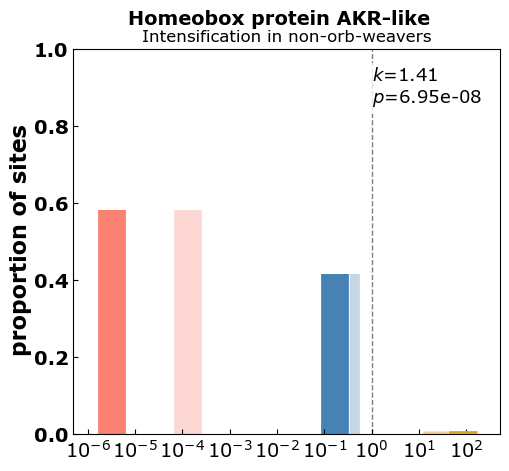

In [36]:
%autoreload 2

plot_omega_single_gene(
    relax_df_fltrd, 
    'N5.HOG0045838', 
    suptitle="Homeobox protein AKR-like",
    subtitle="Intensification in non-orb-weavers",
    k=True,
    transparent=False,
    xlim_min=5E-7,
    xlim_max=500
    )

When the proportion of sites in rate class 3 is set to 0, it means none of the sites are under positive selection (e.g. below). But when some of the omega values themselves are estimated as 0, we might not be able to trust the result.

ω values for N5.HOG0064082: ω1_test=0.0000, ω2_test=0.2709, ω3_test=1.5525,
ω1_ref=0.0000, ω2_ref=0.3670, ω3_ref=1.4015;
Proportions: ω1_test_P=0.6281, ω2_test_P=0.3719, ω3_test_P=0.0000,
ω1_ref_P=0.6281, ω2_ref_P=0.3719, ω3_ref_P=0.0000


(<Figure size 550x500 with 1 Axes>, <Axes: >)

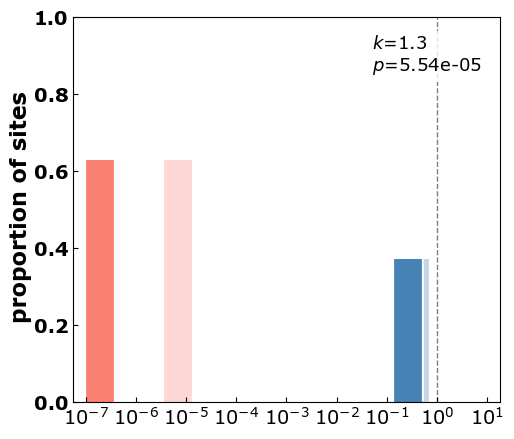

In [37]:
%autoreload 2
plot_omega_single_gene(
    relax_df_fltrd, 
    'N5.HOG0064082', 
    # suptitle="Ecdysteroid phosphate phosphatase",
    # subtitle="Intensification in non-orb-weavers",
    k=True,
    transparent=False,
    # xlim_min=0.005,
    # xlim_max=10
    filename=os.path.join(figures, 'figure_3/relax_intensified_single_gene.png')
    )

plotting marker: omega=288692.6209346128, proportion=0.002816408106279564
plotting marker: omega=959005.2695799496, proportion=0.002816408106279564
ω values for N5.HOG0035885: ω1_test=0.0264, ω2_test=0.0289, ω3_test=959005.2696,
ω1_ref=0.0362, ω2_ref=0.0394, ω3_ref=288692.6209;
Proportions: ω1_test_P=0.9357, ω2_test_P=0.0615, ω3_test_P=0.0028,
ω1_ref_P=0.9357, ω2_ref_P=0.0615, ω3_ref_P=0.0028


(<Figure size 550x500 with 1 Axes>,
 <Axes: title={'center': 'Intensification in non-orb-weavers'}>)

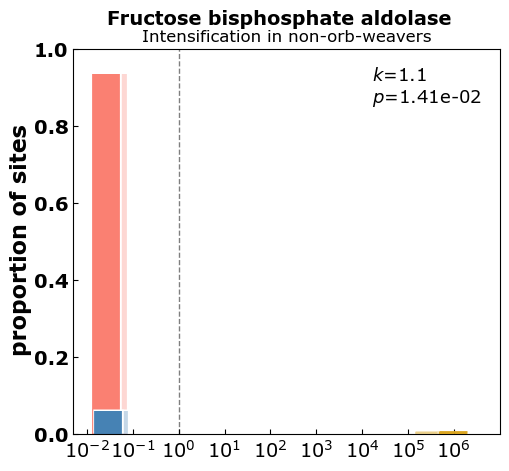

In [38]:
%autoreload 2
plot_omega_single_gene(
    relax_df_fltrd, 
    'N5.HOG0035885', 
    suptitle="Fructose bisphosphate aldolase",
    subtitle="Intensification in non-orb-weavers",
    k=True,
    transparent=False,
    xlim_min=0.005,
    xlim_max=10E6
    )

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
plotting marker: omega=1.30307961817167, proportion=0.004056400551961842
plotting marker: omega=1.351039635354029, proportion=0.004056400551961842
ω values for N5.HOG0067834: ω1_test=0.0330, ω2_test=0.0606, ω3_test=1.3510,
ω1_ref=0.0497, ω2_ref=0.0849, ω3_ref=1.3031;
Proportions: ω1_test_P=0.4329, ω2_test_P=0.5630, ω3_test_P=0.0041,
ω1_ref_P=0.4329, ω2_ref_P=0.5630, ω3_ref_P=0.0041


(<Figure size 550x500 with 1 Axes>,
 <Axes: title={'center': 'Intensification in non-orb-weavers'}>)

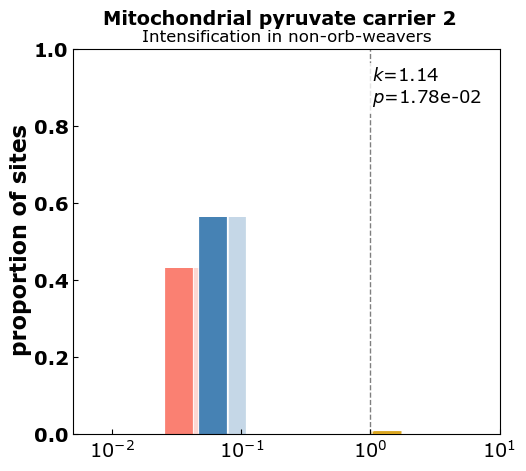

In [39]:
%load_ext autoreload
%autoreload 2
from omega_plots_consolidated import plot_omega_single_gene
plot_omega_single_gene(
    relax_df_fltrd, 
    'N5.HOG0067834', 
    suptitle="Mitochondrial pyruvate carrier 2",
    subtitle="Intensification in non-orb-weavers",
    k=True,
    transparent=False,
    xlim_min=0.005,
    xlim_max=10
    )

## BUSTED-PH: orb-weavers foreground

This one doesn't really look like positive selection...

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
ω values for N5.HOG0044445: ω1_test=0.0000, ω2_test=0.8390, ω3_test=92.7272,
ω1_ref=0.0000, ω2_ref=1.0000, ω3_ref=128.7772;
Proportions: ω1_test_P=0.6165, ω2_test_P=0.3741, ω3_test_P=0.0093,
ω1_ref_P=0.7009, ω2_ref_P=0.2688, ω3_ref_P=0.0303


(<Figure size 550x500 with 1 Axes>,
 <Axes: title={'center': 'Positive selection in orb-weavers'}>)

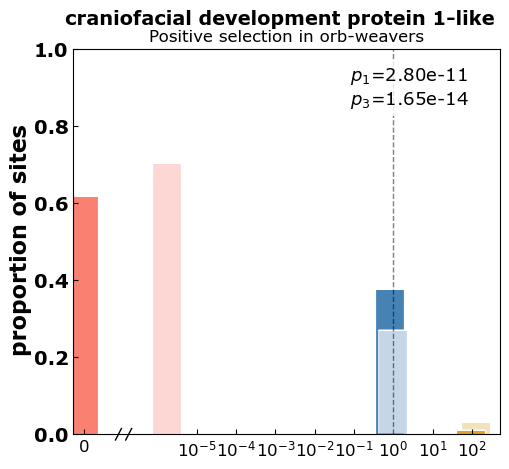

In [40]:

%load_ext autoreload
%autoreload 2
from omega_plots_consolidated import plot_omega_single_gene
plot_omega_single_gene(
    busted_ph_orb_df_fltrd, 
    'N5.HOG0044445', 
    suptitle="craniofacial development protein 1-like",
    subtitle="Positive selection in orb-weavers",
    transparent=False,
    xlim_min=0.000,
    xlim_max=500,
    zorder_2ref=2,
    axis_fontsize=12
    )

I don't think it's a great sign that omega1 is 0

plotting marker: omega=55.2877731965035, proportion=0.0005113927349644539
ω values for N5.HOG0061780: ω1_test=0.0272, ω2_test=0.0443, ω3_test=55.2878,
ω1_ref=0.0121, ω2_ref=0.0146, ω3_ref=1.9847;
Proportions: ω1_test_P=0.9889, ω2_test_P=0.0105, ω3_test_P=0.0005,
ω1_ref_P=0.0311, ω2_ref_P=0.9625, ω3_ref_P=0.0064


(<Figure size 550x500 with 1 Axes>,
 <Axes: title={'center': 'Positive selection in orb-weavers'}>)

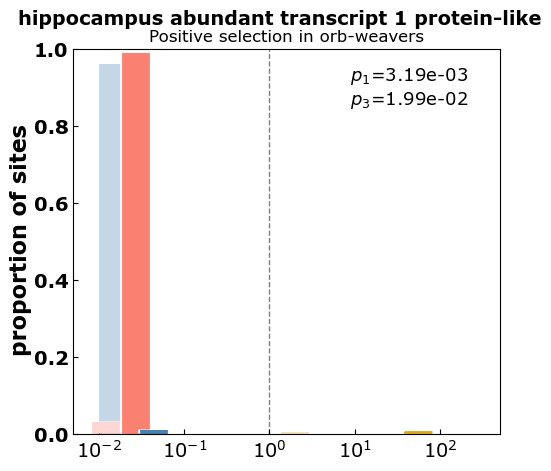

In [41]:
%autoreload 2
from omega_plots_consolidated import plot_omega_single_gene
plot_omega_single_gene(
    busted_ph_orb_df_fltrd, 
    'N5.HOG0061780', 
    suptitle="hippocampus abundant transcript 1 protein-like",
    subtitle="Positive selection in orb-weavers",
    transparent=False,
    xlim_min=0.005,
    xlim_max=500,
    zorder_1ref=2
    )

This might not be relevant at all to arthropods

plotting marker: omega=15.54678969795314, proportion=0.002658358470215471
ω values for N5.HOG0064852: ω1_test=0.0000, ω2_test=0.4213, ω3_test=15.5468,
ω1_ref=0.0480, ω2_ref=0.0480, ω3_ref=1.0000;
Proportions: ω1_test_P=0.5083, ω2_test_P=0.4890, ω3_test_P=0.0027,
ω1_ref_P=0.7579, ω2_ref_P=0.1633, ω3_ref_P=0.0789


(<Figure size 550x500 with 1 Axes>, <Axes: >)

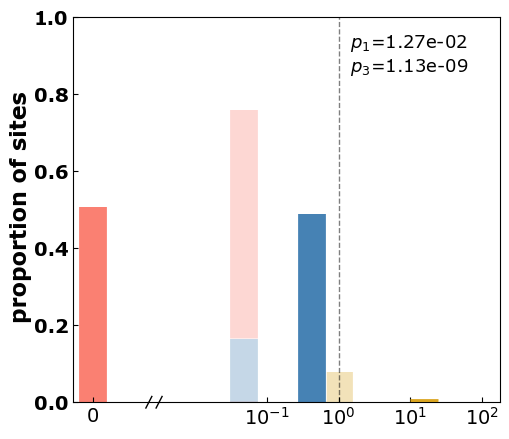

In [42]:
%autoreload 2
from omega_plots_consolidated import plot_omega_single_gene
plot_omega_single_gene(
    busted_ph_orb_df_fltrd, 
    'N5.HOG0064852', 
    # suptitle="decapentaplegic morphogen",
    # subtitle="Positive selection in orb-weavers",
    transparent=False,
    filename=os.path.join(figures, 'figure_4/busted_ph_orb_single_gene.png')
    )

Embryos: It sets up the dorsal-ventral (back-to-belly) body axis early in development.Wings: It organizes the growth and layout of wing imaginal discs, which form the adult fly's wings and legs.

plotting marker: omega=261.3611749984421, proportion=0.0007187813092832799
ω values for N5.HOG0062475: ω1_test=0.0624, ω2_test=0.3772, ω3_test=261.3612,
ω1_ref=0.0000, ω2_ref=0.0713, ω3_ref=0.8224;
Proportions: ω1_test_P=0.9206, ω2_test_P=0.0787, ω3_test_P=0.0007,
ω1_ref_P=0.0432, ω2_ref_P=0.9089, ω3_ref_P=0.0479


(<Figure size 550x500 with 1 Axes>,
 <Axes: title={'center': 'Positive selection in orb-weavers'}>)

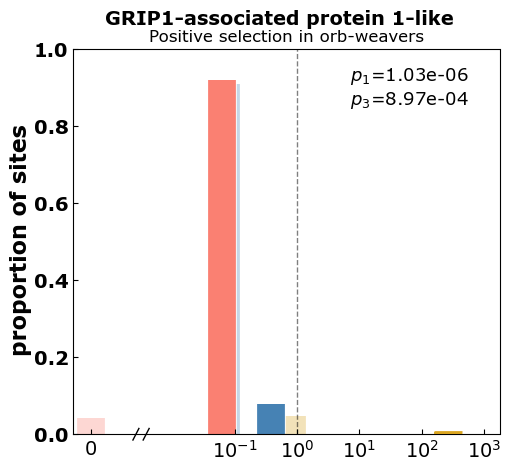

In [43]:

%autoreload 2

from omega_plots_consolidated import plot_omega_single_gene
plot_omega_single_gene(
    busted_ph_orb_df_fltrd, 
    'N5.HOG0062475', 
    suptitle="GRIP1-associated protein 1-like",
    subtitle="Positive selection in orb-weavers",
    transparent=False,
    # filename=os.path.join(figures, 'figure_4/busted_ph_orb_single_gene.png')
    )

GO:0098978 [Name: glutamatergic synapse]; GO:0098998 [Name: extrinsic component of postsynaptic early endosome membrane]; GO:0098837 [Name: postsynaptic recycling endosome]; GO:0098887 [Name: neurotransmitter receptor transport, endosome to postsynaptic membrane]; GO:1905244 [Name: regulation of modification of synaptic structure]

ω values for N5.HOG0065692: ω1_test=0.0000, ω2_test=0.0529, ω3_test=5.8043,
ω1_ref=0.0282, ω2_ref=0.0354, ω3_ref=1.0000;
Proportions: ω1_test_P=0.0876, ω2_test_P=0.9058, ω3_test_P=0.0066,
ω1_ref_P=0.4656, ω2_ref_P=0.5150, ω3_ref_P=0.0194


(<Figure size 550x500 with 1 Axes>,
 <Axes: title={'center': 'Positive selection in orb-weavers'}>)

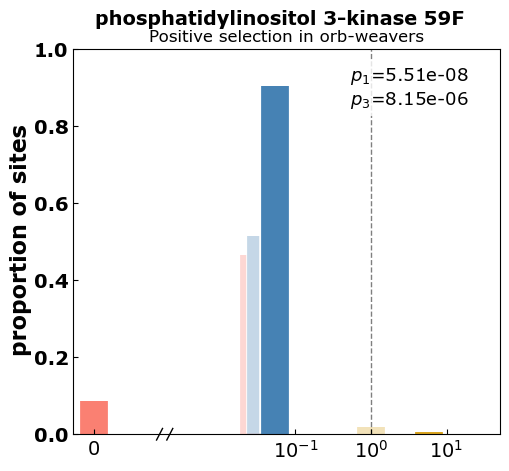

In [44]:
plot_omega_single_gene(
    busted_ph_orb_df_fltrd, 
    'N5.HOG0065692', 
    suptitle="phosphatidylinositol 3-kinase 59F",
    subtitle="Positive selection in orb-weavers",
    transparent=False,
    xlim_max=50,

    )

## BUSTED-PH: non-orb-weavers foreground

plotting marker: omega=315.0025112198966, proportion=0.002743351673439196
ω values for N5.HOG0063079: ω1_test=0.0059, ω2_test=0.3187, ω3_test=6.9856,
ω1_ref=0.0657, ω2_ref=1.0000, ω3_ref=315.0025;
Proportions: ω1_test_P=0.3915, ω2_test_P=0.5610, ω3_test_P=0.0475,
ω1_ref_P=0.7789, ω2_ref_P=0.2184, ω3_ref_P=0.0027


(<Figure size 550x500 with 1 Axes>,
 <Axes: title={'center': 'Positive selection in non-orb-weavers'}>)

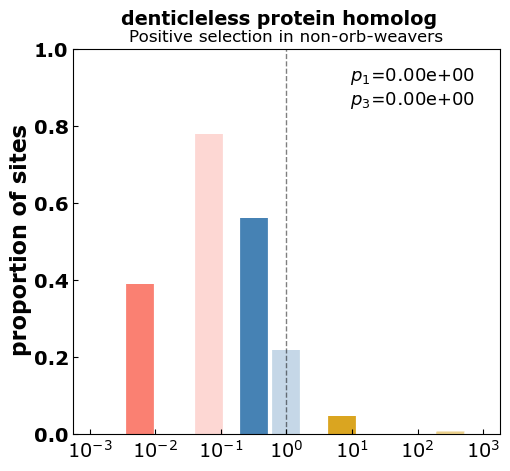

In [45]:
%autoreload 2
from omega_plots_consolidated import plot_omega_single_gene
plot_omega_single_gene(
    busted_ph_non_orb_df_fltrd, 
    'N5.HOG0063079', 
    suptitle="denticleless protein homolog",
    subtitle="Positive selection in non-orb-weavers",
    transparent=False,
    )

Why does this look backwards??

plotting marker: omega=5117.627512871522, proportion=0.003206441554544306
ω values for N5.HOG0056026: ω1_test=0.0554, ω2_test=0.6485, ω3_test=5117.6275,
ω1_ref=0.0000, ω2_ref=0.0057, ω3_ref=0.5226;
Proportions: ω1_test_P=0.8969, ω2_test_P=0.0999, ω3_test_P=0.0032,
ω1_ref_P=0.1938, ω2_ref_P=0.5974, ω3_ref_P=0.2087


(<Figure size 550x500 with 1 Axes>,
 <Axes: title={'center': 'Positive selection in non-orb-weavers'}>)

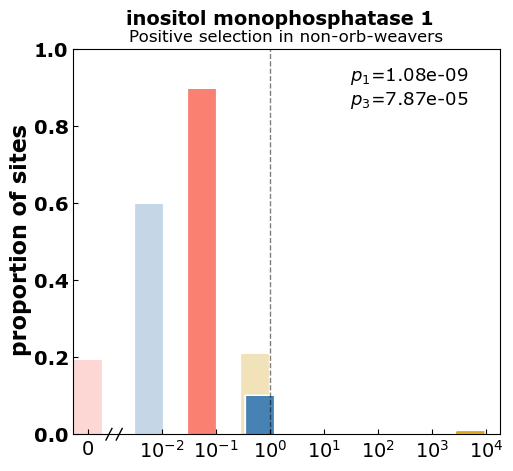

In [46]:
%autoreload 2
from omega_plots_consolidated import plot_omega_single_gene
plot_omega_single_gene(
    busted_ph_non_orb_df_fltrd, 
    'N5.HOG0056026', 
    suptitle="inositol monophosphatase 1",
    subtitle="Positive selection in non-orb-weavers",
    transparent=False,
    # filename=os.path.join(figures, 'figure_4/busted_ph_non_orb_single_gene.png')
    )

ω values for N5.HOG0045838: ω1_test=0.0000, ω2_test=0.4152, ω3_test=6121.6216,
ω1_ref=0.0000, ω2_ref=0.0000, ω3_ref=0.7424;
Proportions: ω1_test_P=0.8062, ω2_test_P=0.1878, ω3_test_P=0.0060,
ω1_ref_P=0.8283, ω2_ref_P=0.0000, ω3_ref_P=0.1717


(<Figure size 550x500 with 1 Axes>,
 <Axes: title={'center': 'Positive selection in non-orb-weavers'}>)

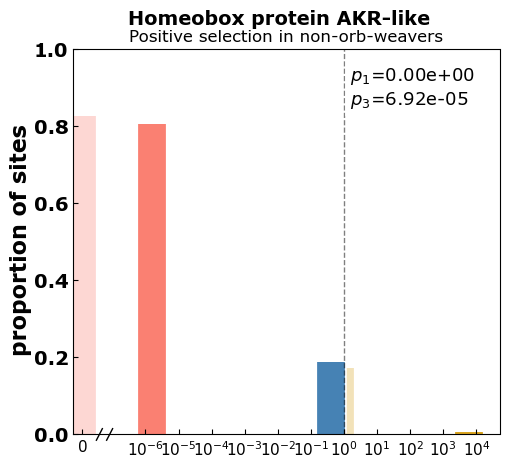

In [47]:
%autoreload 2

plot_omega_single_gene(
    busted_ph_non_orb_df_fltrd, 
    'N5.HOG0045838', 
    suptitle="Homeobox protein AKR-like",
    subtitle="Positive selection in non-orb-weavers",
    transparent=False,
    # xlim_min=5E-7,
    xlim_max=50000,
    axis_fontsize=11
    )

plotting marker: omega=694.954937734851, proportion=0.005768519994558896
ω values for N5.HOG0060063: ω1_test=0.0463, ω2_test=1.0000, ω3_test=1088.8892,
ω1_ref=0.0209, ω2_ref=1.0000, ω3_ref=694.9549;
Proportions: ω1_test_P=0.6299, ω2_test_P=0.3313, ω3_test_P=0.0388,
ω1_ref_P=0.6104, ω2_ref_P=0.3838, ω3_ref_P=0.0058


(<Figure size 550x500 with 1 Axes>,
 <Axes: title={'center': 'Positive selection in non-orb-weavers'}>)

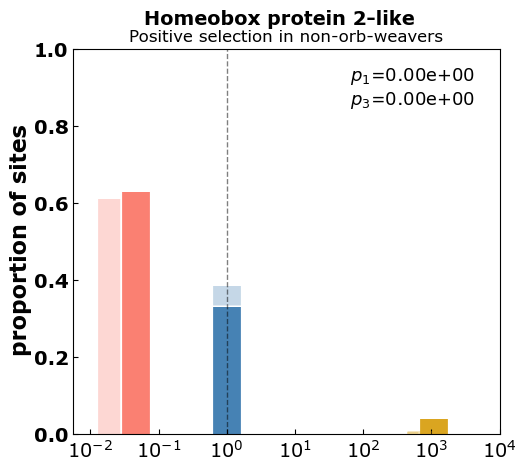

In [48]:

%autoreload 2

plot_omega_single_gene(
    busted_ph_non_orb_df_fltrd, 
    'N5.HOG0060063', 
    suptitle="Homeobox protein 2-like",
    subtitle="Positive selection in non-orb-weavers",
    transparent=False,
    xlim_max=10000
)

plotting marker: omega=25.29843522647452, proportion=0.0005364206964958507
ω values for N5.HOG0069057: ω1_test=0.0110, ω2_test=0.0230, ω3_test=25.2984,
ω1_ref=0.0000, ω2_ref=0.0364, ω3_ref=0.0390;
Proportions: ω1_test_P=0.4794, ω2_test_P=0.5201, ω3_test_P=0.0005,
ω1_ref_P=0.4716, ω2_ref_P=0.2182, ω3_ref_P=0.3102


(<Figure size 550x500 with 1 Axes>,
 <Axes: title={'center': 'Positive selection in non-orb-weavers'}>)

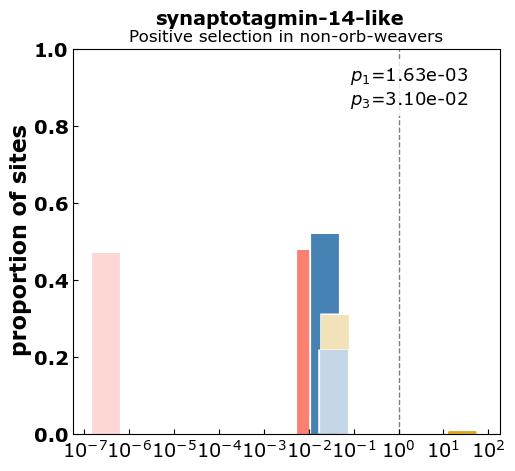

In [49]:

%autoreload 2

plot_omega_single_gene(
    busted_ph_non_orb_df_fltrd, 
    'N5.HOG0069057', 
    suptitle="synaptotagmin-14-like",
    subtitle="Positive selection in non-orb-weavers",
    transparent=False,
    zorder_2ref=3,
    zorder_3ref=2,
    )